In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ghouls-goblins-and-ghosts-boo/train.csv.zip
/kaggle/input/competitions/ghouls-goblins-and-ghosts-boo/sample_submission.csv.zip
/kaggle/input/competitions/ghouls-goblins-and-ghosts-boo/test.csv.zip


In [17]:
train_path = "/kaggle/input/competitions/ghouls-goblins-and-ghosts-boo/train.csv.zip"
df = pd.read_csv(train_path, index_col="id")

In [18]:
df.head()

,bone_length,rotting_flesh,hair_length,has_soul,color,type
id,,,,,,
0,0.354512,0.350839,0.465761,0.781142,clear,Ghoul
1,0.575560,0.425868,0.531401,0.439899,green,Goblin
2,0.467875,0.354330,0.811616,0.791225,black,Ghoul
4,0.776652,0.508723,0.636766,0.884464,black,Ghoul
5,0.566117,0.875862,0.418594,0.636438,green,Ghost


In [19]:
df.describe()

,bone_length,rotting_flesh,hair_length,has_soul
count,371.000000,371.000000,371.000000,371.000000
mean,0.434160,0.506848,0.529114,0.471392
std,0.132833,0.146358,0.169902,0.176129
min,0.061032,0.095687,0.134600,0.009402
25%,0.340006,0.414812,0.407428,0.348002
50%,0.434891,0.501552,0.538642,0.466372
75%,0.517223,0.603977,0.647244,0.600610
max,0.817001,0.932466,1.000000,0.935721


In [20]:
df.isnull().sum()

bone_length      0
rotting_flesh    0
hair_length      0
has_soul         0
color            0
type             0
dtype: int64

The data is clean, that makes our work easier!

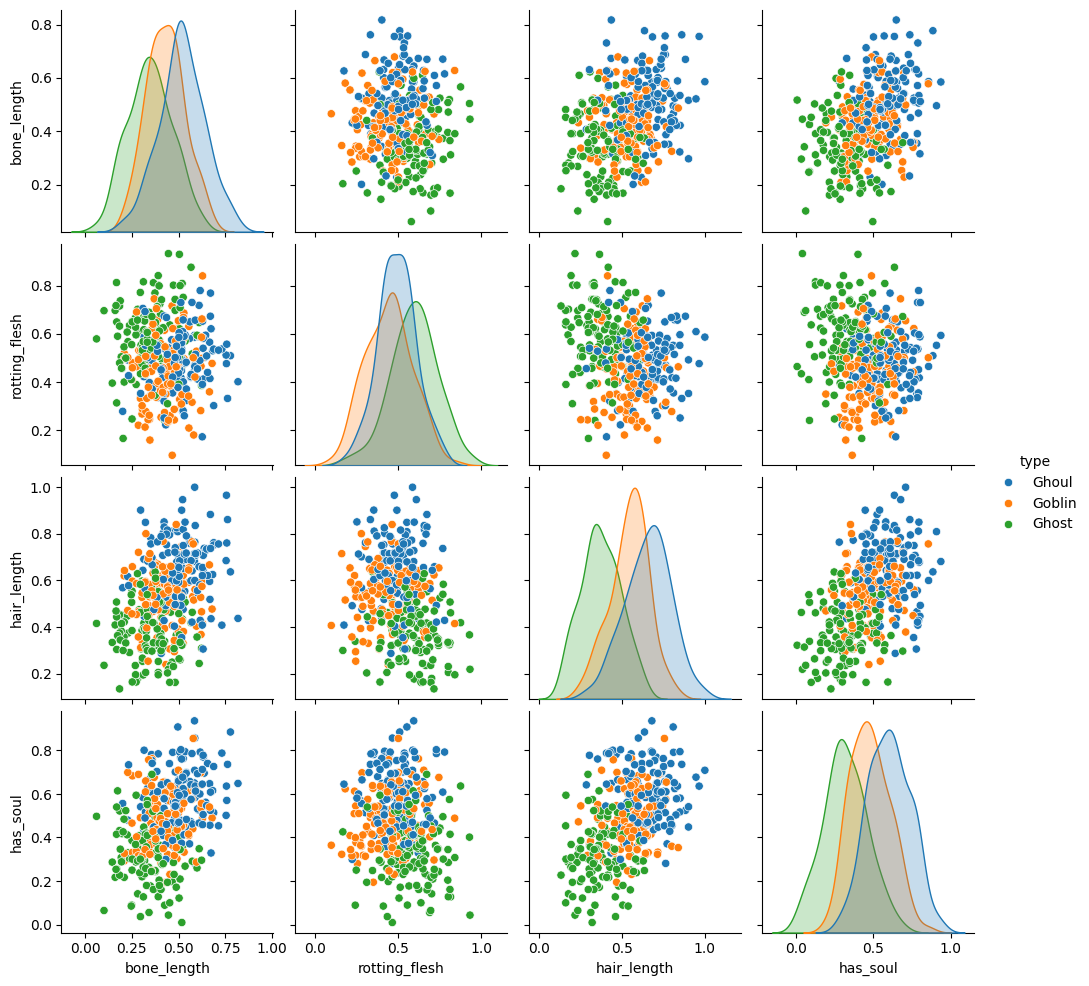

In [21]:
sns.pairplot(df, hue = "type")

<Axes: ylabel='Density'>

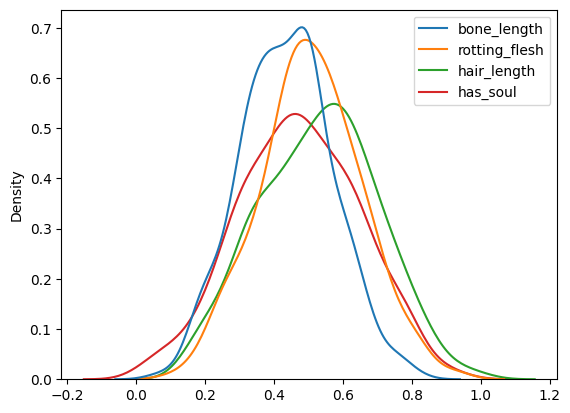

In [22]:
sns.kdeplot(df)

All the features are almost Normally distributed with no outliers

In [23]:
df["color"] = le.fit_transform(df["color"])

cols = list(df.columns)
cols.pop()
print(cols)

X = df.loc[:, cols]
y = df.type

['bone_length', 'rotting_flesh', 'hair_length', 'has_soul', 'color']


In [24]:
from sklearn import tree # Decision Tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=5)
decision_tree_model = tree.DecisionTreeClassifier(max_depth = 10, random_state=5)

In [25]:
decision_tree_model.fit(X_train, y_train)
y_preds = decision_tree_model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

print(f"Accuracy of decision tree classifier = {accuracy_score(y_preds, y_test) * 100}%")

Accuracy of decision tree classifier = 67.85714285714286%


As the accuracy is very low, we need to use GridSearchCV to find the best params for most accuracy

In [27]:
from sklearn.model_selection import GridSearchCV, cross_val_score
params = {"max_depth": range(1, 20), "max_features": range(1, 10)}

tree_grid = GridSearchCV(decision_tree_model, params, cv=10, n_jobs=-1, verbose=True)
tree_grid.fit(X_train, y_train)

Fitting 10 folds for each of 171 candidates, totalling 1710 fits


GridSearchCV(cv=10,
             estimator=DecisionTreeClassifier(max_depth=10, random_state=5),
             n_jobs=-1,
             param_grid={'max_depth': range(1, 20),
                         'max_features': range(1, 10)},
             verbose=True)

In [28]:
tree_grid.best_params_

{'max_depth': 7, 'max_features': 1}

In [29]:
tree_grid.best_score_

np.float64(0.6684615384615384)

In [30]:
y_preds = tree_grid.predict(X_test)
print(f"Accuracy of decision tree classifier after CV = {accuracy_score(y_preds, y_test) * 100}%")

Accuracy of decision tree classifier after CV = 66.07142857142857%


The Accuracy is still very low, so we will not use Decision Tree

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 10)
# for kNN, we need to scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
knn.fit(X_train_scaled, y_train)
y_preds = knn.predict(X_test_scaled)

print(f"Accuracy of kNN = {accuracy_score(y_preds, y_test) * 100}%")

Accuracy of kNN = 66.96428571428571%


In [33]:
from sklearn.pipeline import Pipeline

knn_pipe = Pipeline(
    [("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_jobs=-1))]
)

knn_params = {"knn__n_neighbors": range(1, 10)}

knn_grid = GridSearchCV(knn_pipe, knn_params, cv=10, n_jobs=-1, verbose=True)

knn_grid.fit(X_train, y_train)

knn_grid.best_params_, knn_grid.best_score_

Fitting 10 folds for each of 9 candidates, totalling 90 fits


({'knn__n_neighbors': 8}, np.float64(0.7064615384615384))

In [34]:
y_preds = knn_grid.predict(X_test)

print(f"Accuracy of kNN after CV = {accuracy_score(y_preds, y_test) * 100}%")

Accuracy of kNN after CV = 65.17857142857143%


Accuracy for kNN is lower than DecisionTree

In [35]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(n_estimators = 10, max_depth = 5, random_state=5)

In [36]:
random_forest_model.fit(X_train, y_train)
y_preds = random_forest_model.predict(X_test)

print(f"Accuracy of Random Forst = {accuracy_score(y_preds, y_test) * 100}%")

Accuracy of Random Forst = 71.42857142857143%


In [37]:
params = {"n_estimators": range(1, 100), "max_depth": range(1, 11), "max_features": range(1, 6)}

random_forest_grid = GridSearchCV(random_forest_model, params, cv=5, n_jobs=-1, verbose=True)
random_forest_grid.fit(X_train, y_train)

Fitting 5 folds for each of 4950 candidates, totalling 24750 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_depth=5, n_estimators=10,
                                              random_state=5),
             n_jobs=-1,
             param_grid={'max_depth': range(1, 11), 'max_features': range(1, 6),
                         'n_estimators': range(1, 100)},
             verbose=True)

In [38]:
random_forest_grid.best_params_, random_forest_grid.best_score_

({'max_depth': 4, 'max_features': 5, 'n_estimators': 71},
 np.float64(0.7416289592760181))

In [39]:
y_preds = random_forest_grid.predict(X_test)

print(f"Accuracy of Random Forest after CV = {accuracy_score(y_preds, y_test) * 100}%")

Accuracy of Random Forest after CV = 74.10714285714286%


Highest accuracy is achieved in Random Classifier

In [40]:
sub_path = "/kaggle/input/competitions/ghouls-goblins-and-ghosts-boo/sample_submission.csv.zip"
sub = pd.read_csv(sub_path, index_col="id")
sub.head()

,type
id,
3,Ghost
6,Ghost
9,Ghost
10,Ghost
13,Ghost


In [41]:
test_df_path = "/kaggle/input/competitions/ghouls-goblins-and-ghosts-boo/test.csv.zip"
test_df = pd.read_csv(test_df_path, index_col = "id")
test_df["color"] = le.fit_transform(test_df["color"])

test_df.head()

,bone_length,rotting_flesh,hair_length,has_soul,color
id,,,,,
3,0.471774,0.387937,0.706087,0.698537,0
6,0.427332,0.645024,0.565558,0.451462,5
9,0.549602,0.491931,0.660387,0.449809,0
10,0.638095,0.682867,0.471409,0.356924,5
13,0.361762,0.583997,0.377256,0.276364,0


In [42]:
y_pred_sub = random_forest_grid.predict(test_df)

In [47]:
submissions = pd.DataFrame({"id": test_df.index, "type": y_pred_sub})

In [48]:
submissions.head()

,id,type
0,3,Ghoul
1,6,Goblin
2,9,Ghoul
3,10,Ghost
4,13,Ghost


In [52]:
submissions.head()
submissions.to_csv("submission.csv", index = False)

In [53]:
pd.read_csv("/kaggle/working/submission.csv").head()

,id,type
0,3,Ghoul
1,6,Goblin
2,9,Ghoul
3,10,Ghost
4,13,Ghost
